In [1]:
#importing libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from matplotlib.colors import ListedColormap
import numpy as np

In [2]:
#load dataset
iris = load_iris()

df = pd.DataFrame(iris.data, columns= iris.feature_names)
df['target'] = iris.target

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [3]:
#normalize features
x = df.iloc[:, :4]
y = df['target']

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2, random_state=42)


In [4]:
#applying kneighbor classifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train, y_train)
y_pred = knn.predict(x_test)
print("Model trained successfully")

Model trained successfully


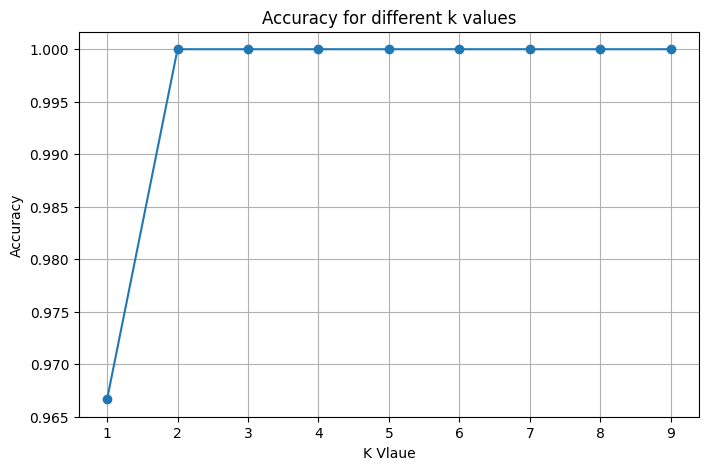

Best K : 2
Highest Accuracy: 1.0


In [5]:
#knn with different k values
k_values = range(1,10)
accuracies = []

for k in k_values:
  model = KNeighborsClassifier(n_neighbors=k)
  model.fit(x_train,y_train)
  pred = model.predict(x_test)
  accuracies.append(accuracy_score(y_test, pred))

plt.figure(figsize=(8,5))
plt.plot(k_values, accuracies, marker='o')
plt.xlabel("K Vlaue")
plt.ylabel("Accuracy")
plt.title("Accuracy for different k values")
plt.grid(True)
plt.show()

best_k = k_values[np.argmax(accuracies)]
print("Best K :", best_k)
print("Highest Accuracy:", max(accuracies))

Accuracy: 1.0


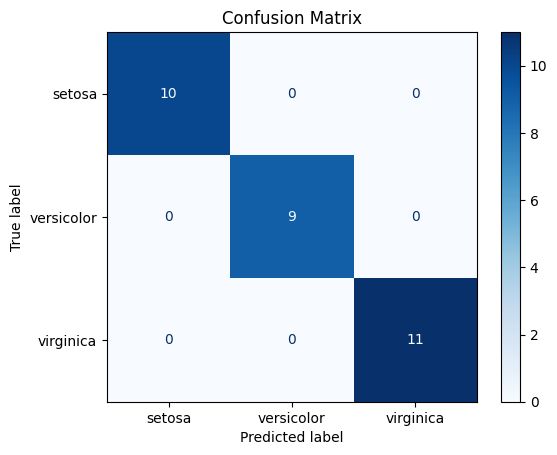

In [7]:
#accuraacy and confusion matrix
best_model = KNeighborsClassifier(n_neighbors=best_k)
best_model.fit(x_train, y_train)

y_pred = best_model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=iris.target_names)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

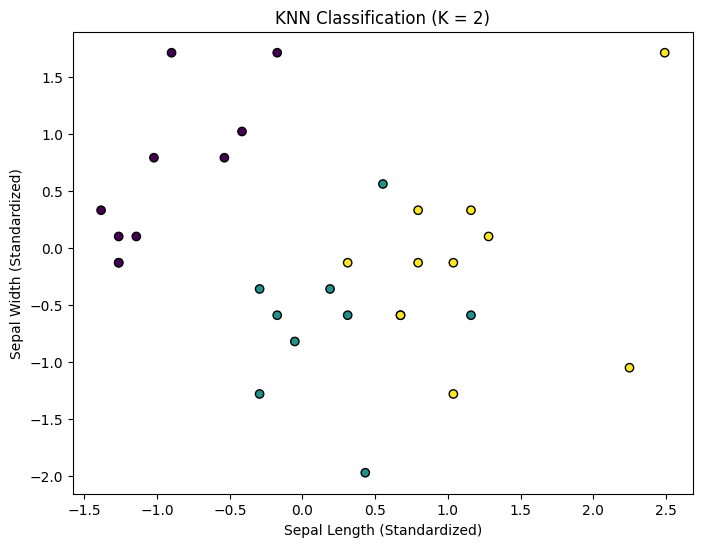

In [11]:
# visualization of first two features
plt.figure(figsize=(8,6))

plt.scatter(x_test[:,0], x_test[:,1], c=y_pred, cmap='viridis', edgecolor='black')

plt.xlabel("Sepal Length (Standardized)")
plt.ylabel("Sepal Width (Standardized)")
plt.title(f"KNN Classification (K = {best_k})")

plt.show()